# __<u>Initialize Cloud-AI Engine</u>__ 
> Selected python version == 3.9.13
>> To access cmd: py -3.9 -m pip ....
>>> - py -3.9 -m pip install --upgrade pip
>>> - py -3.9 -m pip install "tensorflow-gpu<2.10"
>>> - py -3.9 -m pip install tensorflow-addons==0.19.0 (link: https://github.com/tensorflow/addons)

> Install/Verify Packages

In [117]:
# %pip install --user --upgrade pandas
# %pip install --user --upgrade "sqlalchemy<2.0"
# %pip install --user --upgrade mariadb
# %pip install --user --upgrade -U matplotlib
# %pip install -U scikit-learn
# %pip install pydot
# %pip install tensorflow-addons==0.19.0
# %pip install xgboost
# %pip install --upgrade pip
# %pip install "numpy<2"

> Import Libraries

In [118]:
# stdlib
import os
import sys
import time
import pickle
import random
from math import sqrt

# third-party
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)

import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow_addons.layers import MultiHeadAttention
from keras import backend
from keras.models import Model, load_model
from keras.layers import (Input, Dense, LSTM, Bidirectional, GRU, Conv1D, SimpleRNN,
                          Concatenate, Dropout, BatchNormalization, Reshape, Flatten,
                          MaxPooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D,
                          LayerNormalization)
from keras.utils.vis_utils import plot_model

print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"matplotlib  {matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"tensorflow  {tf.__version__}")
print(f"tf-addons   {tfa.__version__}")
print(f"keras       {tf.keras.__version__}")
print(f"python      {sys.version}")

numpy       1.26.4
pandas      2.3.2
matplotlib  3.9.4
scikit-learn 1.6.1
tensorflow  2.9.3
tf-addons   0.19.0
keras       2.9.0
python      3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]


In [119]:
import sys, os
sys.path.append(os.path.abspath('..'))   # add the IGPS project root to the path

import importlib
import Library.modelDevelopment
importlib.reload(Library.modelDevelopment)

<module 'Library.modelDevelopment' from 'f:\\RBM\\Educational\\UTS.au\\Research\\[P] KMU==IGPS in Solar Plants\\Firmware\\IGPS\\Library\\modelDevelopment.py'>

# __<u>Configure Simulation Setup</u>__

> Import and Export Directory

In [120]:
Site_Info   = 'Site-02'
expDataDir  = '../Export/Data/' + Site_Info + '/' 
impDataDir  = expDataDir
expModelDir = '../Export/Model/' + Site_Info + '/'
expFigDir   = '../Export/Figure/' + Site_Info + '/'

> Define colunmns and rows of pandas output

In [121]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 30)

> Work on GPU utilization
>> 1. https://www.tensorflow.org/guide/gpu#limiting_gpu_memory_growth
>> 2. https://www.tensorflow.org/guide/gpu#using_multiple_gpus
>> 3. https://www.tensorflow.org/guide/gpu#using_a_single_gpu_on_a_multi-gpu_system

In [122]:
### Limiting GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
print('Available Physical GPUs=>'+str(gpus))
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print('Configured Logical GPUs=>'+str(logical_gpus))
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

Available Physical GPUs=>[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configured Logical GPUs=>[LogicalDevice(name='/device:GPU:0', device_type='GPU')]


> Define GPU which will be used

In [123]:
selectGPU   = 0
selectedGPU ='/device:GPU:'+ str(selectGPU)
selectedGPU

'/device:GPU:0'

# <u>Getting __Datasets__</u>

In [124]:
# ---------- Training Data ----------
PV1_train = pd.read_csv(f"{impDataDir}Site_02_PV1_Scaled_Train.csv", index_col=0, parse_dates=True)
PV2_train = pd.read_csv(f"{impDataDir}Site_02_PV2_Scaled_Train.csv", index_col=0, parse_dates=True)
PV3_train = pd.read_csv(f"{impDataDir}Site_02_PV3_Scaled_Train.csv", index_col=0, parse_dates=True)

# ---------- Testing Data ----------
PV1_test = pd.read_csv(f"{impDataDir}Site_02_PV1_Scaled_Test.csv", index_col=0, parse_dates=True)
PV2_test = pd.read_csv(f"{impDataDir}Site_02_PV2_Scaled_Test.csv", index_col=0, parse_dates=True)
PV3_test = pd.read_csv(f"{impDataDir}Site_02_PV3_Scaled_Test.csv", index_col=0, parse_dates=True)

In [125]:
/break

SyntaxError: invalid syntax (3312640612.py, line 1)

# <u>Working with __PV-1__</u>

> Windowing and Splitting to Train and Validation

In [ ]:
from Library.modelDevelopment import make_windows, split_train_val

X,y = make_windows(PV1_train, input_len=168, output_len=24, stride=1)
X_train, y_train, X_val, y_val = split_train_val(X, y, val_frac=0.20, gap=168+24)

print('='*50)
print("Training and Validation Set Shapes for PV1_train:")
print('-'*50)
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print('-'*50)
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_val shape: {y_val.shape}')
print('='*50)

Training and Validation Set Shapes for PV1_train:
--------------------------------------------------
X shape: (47257, 168, 7)
y shape: (47257, 24)
--------------------------------------------------
X_train shape: (37614, 168, 7)
y_train shape: (37614, 24)
X_val shape: (9451, 168, 7)
y_val shape: (9451, 24)


> __PV1:__ Training __LSTM__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = LSTM  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = LSTM  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = LSTM  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
x   = LSTM  (units= 32, return_sequences=True)(x)       # Fourth LSTM Layer
v   = GlobalAveragePooling1D()(x)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_LSTM  = Model(inputs=[inp], outputs=out)          # Define Model
model_LSTM.compile(optimizer='adam', loss='mse')        # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_LSTM.summary())                             # Summarize Model Development
plot_model(model_LSTM, to_file=f'{expFigDir}model_LSTM.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                            # Clear Previous History
    model_LSTM.compile(optimizer="Adam", loss="mse", metrics=["mae", "mse"])    # Compile Model with Metrics
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                           # Save Best Model
        f'{expModelDir}PV1_model_LSTM.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                             # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_LSTM.fit(                                               # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 168, 7)]          0         
                                                                 
 lstm (LSTM)                 (None, 168, 128)          69632     
                                                                 
 lstm_1 (LSTM)               (None, 168, 64)           49408     
                                                                 
 lstm_2 (LSTM)               (None, 168, 48)           21696     
                                                                 
 lstm_3 (LSTM)               (None, 168, 32)           10368     
                                                                 
 global_average_pooling1d (G  (None, 32)               0         
 lobalAveragePooling1D)                                          
                                                             

History saved to:
  ../Export/History/Site-02/history-LSTM Model for SolarPlant-1 (Gyeongju).pkl
  ../Export/History/Site-02/history-LSTM Model for SolarPlant-1 (Gyeongju).json


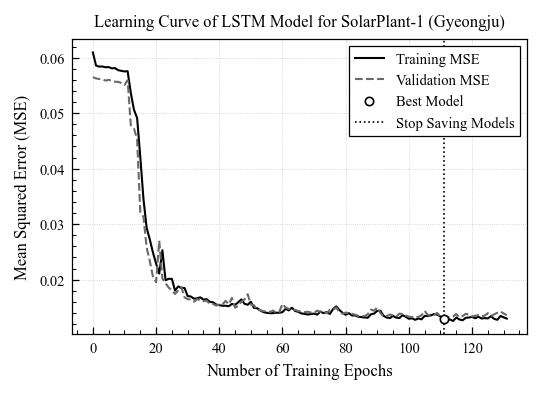

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
importlib.reload(Library.modelDevelopment)
from Library.modelDevelopment import plot_training_validation_loss
plot_training_validation_loss(history=history, model_Name='LSTM Model for SolarPlant-1 (Gyeongju)', patience=20)


In [ ]:
# from Library.modelDevelopment import save_history, load_history
# hist = load_history('LSTM Model for SolarPlant-1 (Gyeongju)')
# plot_training_validation_loss(history=hist,
#                               model_Name='LSTM Model for SolarPlant-1 (Gyeongju)',
#                               patience=20,
#                               save_hist=False)  # already saved

In [ ]:
# Load Best Model
model_LSTM  = load_model(expModelDir + 'PV1_model_LSTM.h5')
# Evaluation and Output
import joblib
model_Scaler = joblib.load(f"{expModelDir}scaler_Site_02.joblib")

from Library.modelDevelopment import evaluate_model
Eval_LSTM, Predict_LSTM = evaluate_model('LSTM', model_LSTM, model_Scaler, X_val, y_val)
print(Eval_LSTM)

296/296 [==============================] - 4s 12ms/step
  Model       MAE         MSE      RMSE        R2
0  LSTM  5.748621  118.585342  10.88969  0.744174


> __PV1:__ Training __MHSA-LSTM__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = LSTM  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = LSTM  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = LSTM  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
x   = LSTM  (units= 32, return_sequences=True)(x)       # Fourth LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=32)([x, x])  # attention after it
# v   = Flatten()(a)                                      # Flatten the output of attention layer
v   = GlobalAveragePooling1D()(a)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_MHSA_LSTM  = Model(inputs=[inp], outputs=out)     # Define Model
model_MHSA_LSTM.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_MHSA_LSTM.summary())                        # Summarize Model Development
plot_model(model_MHSA_LSTM, to_file=f'{expFigDir}model_MHSA_LSTM.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_MHSA_LSTM.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV1_model_MHSA_LSTM.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_MHSA_LSTM.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 lstm (LSTM)                    (None, 168, 128)     69632       ['input_1[0][0]']                
                                                                                                  
 lstm_1 (LSTM)                  (None, 168, 64)      49408       ['lstm[0][0]']                   
                                                                                                  
 lstm_2 (LSTM)                  (None, 168, 48)      21696       ['lstm_1[0][0]']                 
                                                                                              

History saved to:
  ../Export/History/Site-02/history-MHSA-LSTM Model for SolarPlant-1 (Gyeongju).pkl
  ../Export/History/Site-02/history-MHSA-LSTM Model for SolarPlant-1 (Gyeongju).json


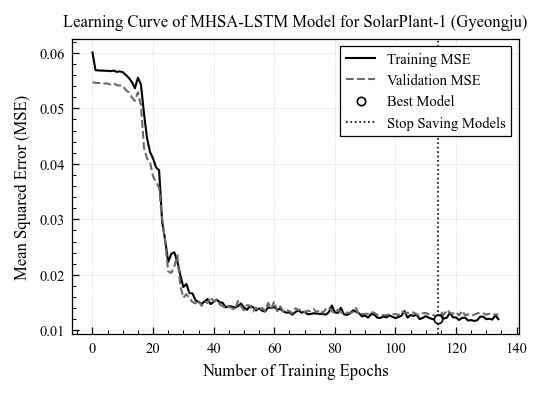

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='MHSA-LSTM Model for SolarPlant-1 (Gyeongju)', patience=20)

In [ ]:
Eval_MHSA_LSTM, Predict_MHSA_LSTM = evaluate_model('MHSA-LSTM', model_MHSA_LSTM, model_Scaler, X_val, y_val)
print(Eval_MHSA_LSTM)

296/296 [==============================] - 5s 16ms/step
       Model       MAE         MSE       RMSE        R2
0  MHSA-LSTM  5.421873  115.772141  10.759746  0.750243


> __PV1:__ Training __TCSA-LSTM__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = LSTM  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = LSTM  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = LSTM  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=48)([x, x])  # attention after it
x   = LSTM  (units= 32)(a)                              # Fourth LSTM Layer
out = Dense (units= 24, activation='relu')(x)           # Output Layer
model_TCSA_LSTM  = Model(inputs=[inp], outputs=out)     # Define Model
model_TCSA_LSTM.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_TCSA_LSTM.summary())                        # Summarize Model Development
plot_model(model_TCSA_LSTM, to_file=f'{expFigDir}model_TCSA_LSTM.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_TCSA_LSTM.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV1_model_TCSA_LSTM.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_TCSA_LSTM.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 lstm (LSTM)                    (None, 168, 128)     69632       ['input_1[0][0]']                
                                                                                                  
 lstm_1 (LSTM)                  (None, 168, 64)      49408       ['lstm[0][0]']                   
                                                                                                  
 lstm_2 (LSTM)                  (None, 168, 48)      21696       ['lstm_1[0][0]']                 
                                                                                              

History saved to:
  ../Export/History/Site-02/history-TCSA-LSTM Model for SolarPlant-1 (Gyeongju).pkl
  ../Export/History/Site-02/history-TCSA-LSTM Model for SolarPlant-1 (Gyeongju).json


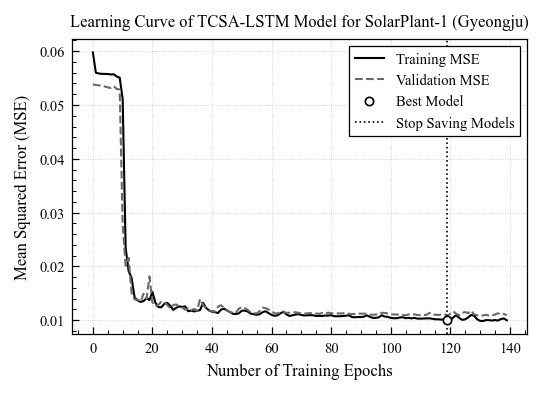

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='TCSA-LSTM Model for SolarPlant-1 (Gyeongju)', patience=20)

In [ ]:
Eval_TCSA_LSTM, Predict_TCSA_LSTM = evaluate_model('TCSA-LSTM', model_TCSA_LSTM, model_Scaler, X_val, y_val)
print(Eval_TCSA_LSTM)

296/296 [==============================] - 5s 16ms/step
       Model       MAE        MSE      RMSE        R2
0  TCSA-LSTM  4.894757  98.712532  9.935418  0.787046


> __PV1:__ Training __GRU__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = GRU  (units=128, return_sequences=True)(inp)      # First GRU Layer
x   = GRU  (units= 64, return_sequences=True)(x)        # Second GRU Layer
x   = GRU  (units= 48, return_sequences=True)(x)        # Third GRU Layer
x   = GRU  (units= 32, return_sequences=True)(x)        # Fourth GRU Layer
v   = GlobalAveragePooling1D()(x)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_GRU  = Model(inputs=[inp], outputs=out)           # Define Model
model_GRU.compile(optimizer='adam', loss='mse')         # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_GRU.summary())                              # Summarize Model Development
plot_model(model_GRU, to_file=f'{expFigDir}model_GRU.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                            # Clear Previous History
    model_GRU.compile(optimizer="Adam", loss="mse", metrics=["mae", "mse"])     # Compile Model with Metrics
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                           # Save Best Model
        f'{expModelDir}PV1_model_GRU.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                             # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_GRU.fit(                                                # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 168, 7)]          0         
                                                                 
 gru (GRU)                   (None, 168, 128)          52608     
                                                                 
 gru_1 (GRU)                 (None, 168, 64)           37248     
                                                                 
 gru_2 (GRU)                 (None, 168, 48)           16416     
                                                                 
 gru_3 (GRU)                 (None, 168, 32)           7872      
                                                                 
 global_average_pooling1d (G  (None, 32)               0         
 lobalAveragePooling1D)                                          
                                                             

History saved to:
  ../Export/History/Site-02/history-GRU Model for SolarPlant-1 (Gyeongju).pkl
  ../Export/History/Site-02/history-GRU Model for SolarPlant-1 (Gyeongju).json


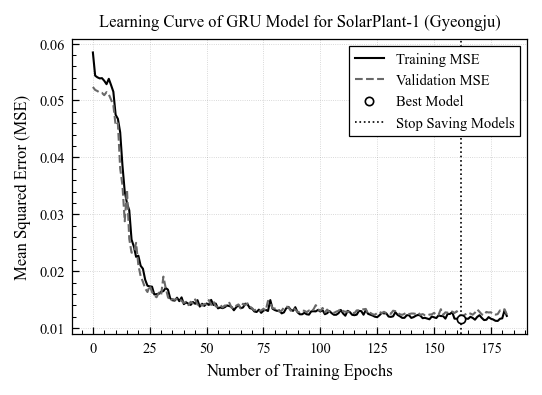

In [ ]:
plot_training_validation_loss(history=history, model_Name='GRU Model for SolarPlant-1 (Gyeongju)', patience=20)

In [ ]:
Eval_GRU, Predict_GRU = evaluate_model('GRU', model_GRU, model_Scaler, X_val, y_val)
print(Eval_GRU)

296/296 [==============================] - 5s 14ms/step
  Model       MAE         MSE       RMSE       R2
0   GRU  5.439844  112.385376  10.601197  0.75755


> __PV1:__ Training __MHSA-GRU__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = GRU  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = GRU  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = GRU  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
x   = GRU  (units= 32, return_sequences=True)(x)       # Fourth LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=32)([x, x])  # attention after it
# v   = Flatten()(a)                                      # Flatten the output of attention layer
v   = GlobalAveragePooling1D()(a)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_MHSA_GRU  = Model(inputs=[inp], outputs=out)     # Define Model
model_MHSA_GRU.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_MHSA_GRU.summary())                        # Summarize Model Development
plot_model(model_MHSA_GRU, to_file=f'{expFigDir}model_MHSA_GRU.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_MHSA_GRU.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV1_model_MHSA_GRU.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_MHSA_GRU.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 gru (GRU)                      (None, 168, 128)     52608       ['input_1[0][0]']                
                                                                                                  
 gru_1 (GRU)                    (None, 168, 64)      37248       ['gru[0][0]']                    
                                                                                                  
 gru_2 (GRU)                    (None, 168, 48)      16416       ['gru_1[0][0]']                  
                                                                                              

History saved to:
  ../Export/History/Site-02/history-MHSA-GRU Model for SolarPlant-1 (Gyeongju).pkl
  ../Export/History/Site-02/history-MHSA-GRU Model for SolarPlant-1 (Gyeongju).json


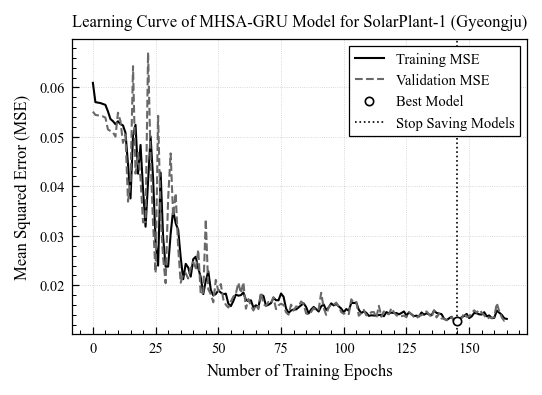

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='MHSA-GRU Model for SolarPlant-1 (Gyeongju)', patience=20)

In [ ]:
Eval_MHSA_GRU, Predict_MHSA_GRU = evaluate_model('MHSA-GRU', model_MHSA_GRU, model_Scaler, X_val, y_val)
print(Eval_MHSA_GRU)

296/296 [==============================] - 5s 15ms/step
      Model       MAE        MSE       RMSE        R2
0  MHSA-GRU  5.568651  117.32003  10.831437  0.746904


> __PV1:__ Training __TCSA-GRU__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = GRU  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = GRU  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = GRU  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=48)([x, x])  # attention after it
x   = GRU  (units= 32)(a)                              # Fourth LSTM Layer
out = Dense (units= 24, activation='relu')(x)           # Output Layer
model_TCSA_GRU  = Model(inputs=[inp], outputs=out)     # Define Model
model_TCSA_GRU.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_TCSA_GRU.summary())                        # Summarize Model Development
plot_model(model_TCSA_GRU, to_file=f'{expFigDir}model_TCSA_GRU.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_TCSA_GRU.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV1_model_TCSA_GRU.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_TCSA_GRU.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 gru (GRU)                      (None, 168, 128)     52608       ['input_1[0][0]']                
                                                                                                  
 gru_1 (GRU)                    (None, 168, 64)      37248       ['gru[0][0]']                    
                                                                                                  
 gru_2 (GRU)                    (None, 168, 48)      16416       ['gru_1[0][0]']                  
                                                                                              

History saved to:
  ../Export/History/Site-02/history-TCSA-GRU Model for SolarPlant-1 (Gyeongju).pkl
  ../Export/History/Site-02/history-TCSA-GRU Model for SolarPlant-1 (Gyeongju).json


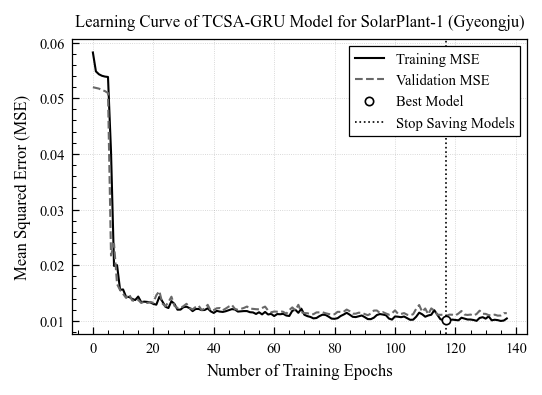

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='TCSA-GRU Model for SolarPlant-1 (Gyeongju)', patience=20)

In [ ]:
Eval_TCSA_GRU, Predict_TCSA_GRU = evaluate_model('TCSA-GRU', model_TCSA_GRU, model_Scaler, X_val, y_val)
print(Eval_TCSA_GRU)

296/296 [==============================] - 5s 14ms/step
      Model       MAE         MSE       RMSE        R2
0  TCSA-GRU  4.969282  103.221634  10.159805  0.777319


> __PV1:__ Training __MHSA-Transformer__ Model

In [ ]:
import numpy as np                                       # needed for positional encoding

# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- Positional Encoding Layer (fixed sinusoidal) -----
class PositionalEncoding(tf.keras.layers.Layer):        # adds timestep order to embeddings
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        pos   = np.arange(seq_len)[:, None]
        i     = np.arange(d_model)[None, :]
        angle = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        pe              = np.zeros((seq_len, d_model), dtype=np.float32)
        pe[:, 0::2]     = np.sin(angle[:, 0::2])
        pe[:, 1::2]     = np.cos(angle[:, 1::2])
        self.pe         = tf.constant(pe[None, ...])    # (1, seq_len, d_model)
    def call(self, x):
        return x + self.pe                              # inject positions
    def get_config(self):
        return super().get_config()

# ----- Transformer Encoder Block -----
def transformer_encoder(x, head_size, num_heads, ff_dim):
    a    = MultiHeadAttention(num_heads=num_heads, head_size=head_size)([x, x]) # Self-Attention
    ff   = Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(a)          # Feed-Forward Network
    ff   = Conv1D(filters=x.shape[-1], kernel_size=1)(ff)                       # Project back to input dimension
    return ff

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                                             # Define the input
x   = Dense(32)(inp)                                                    # project 7 features -> model dim
x   = PositionalEncoding(seq_len=168, d_model=32)(x)                    # add timestep order
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # First Encoder Block
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # Second Encoder Block
v   = GlobalAveragePooling1D()(x)                                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)                           # Output Layer
model_MHSA_Transformer = Model(inputs=[inp], outputs=out)               # Define Model
model_MHSA_Transformer.compile(optimizer='adam', loss='mse')            # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_MHSA_Transformer.summary())                                 # Summarize Model Development
plot_model(model_MHSA_Transformer, to_file=f'{expFigDir}model_MHSA_Transformer.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                    # Clear Previous History
    model_MHSA_Transformer.compile(                                     # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                   # Save Best Model
        f'{expModelDir}PV1_model_MHSA_Transformer.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_MHSA_Transformer.fit(                           # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024,
        validation_data=(X_val, y_val), verbose=1,
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 dense (Dense)                  (None, 168, 32)      256         ['input_1[0][0]']                
                                                                                                  
 positional_encoding (Positiona  (None, 168, 32)     0           ['dense[0][0]']                  
 lEncoding)                                                                                       
                                                                                                  
 multi_head_attention (MultiHea  (None, 168, 32)     49184       ['positional_encoding[0][0]',

In [ ]:
# model_MHSA_Transformer = load_model(f'{expModelDir}PV1_model_MHSA_Transformer.h5',
#                                     custom_objects={'PositionalEncoding': PositionalEncoding})

History saved to:
  ../Export/History/Site-02/history-MHSA-Transformer Model for SolarPlant-1 (Gyeongju).pkl
  ../Export/History/Site-02/history-MHSA-Transformer Model for SolarPlant-1 (Gyeongju).json


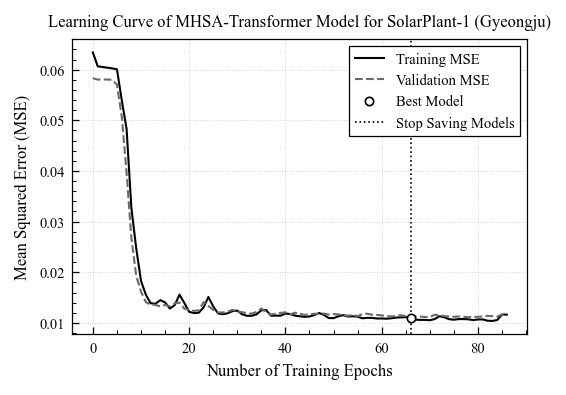

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
from Library.modelDevelopment import plot_training_validation_loss
plot_training_validation_loss(history=history, model_Name='MHSA-Transformer Model for SolarPlant-1 (Gyeongju)', patience=20)

In [ ]:
import joblib
model_Scaler = joblib.load(f"{expModelDir}scaler_Site_02.joblib")

from Library.modelDevelopment import evaluate_model
Eval_MHSA_Transformer, Predict_MHSA_Transformer = evaluate_model('MHSA-Transformer', model_MHSA_Transformer, model_Scaler, X_val, y_val)
print(Eval_MHSA_Transformer)

296/296 [==============================] - 1s 2ms/step
              Model       MAE         MSE       RMSE        R2
0  MHSA-Transformer  5.142516  103.098869  10.153761  0.777583


> __PV1:__ Training __TCSA-Transformer__ Model

In [ ]:
import numpy as np                                       # needed for positional encoding

# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- Positional Encoding Layer (fixed sinusoidal) -----
class PositionalEncoding(tf.keras.layers.Layer):        # adds timestep order to embeddings
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        pos   = np.arange(seq_len)[:, None]
        i     = np.arange(d_model)[None, :]
        angle = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        pe              = np.zeros((seq_len, d_model), dtype=np.float32)
        pe[:, 0::2]     = np.sin(angle[:, 0::2])
        pe[:, 1::2]     = np.cos(angle[:, 1::2])
        self.pe         = tf.constant(pe[None, ...])    # (1, seq_len, d_model)
    def call(self, x):
        return x + self.pe                              # inject positions
    def get_config(self):
        return super().get_config()

# ----- Transformer Encoder Block -----
def transformer_encoder(x, head_size, num_heads, ff_dim):
    a    = MultiHeadAttention(num_heads=num_heads, head_size=head_size)([x, x]) # Self-Attention
    ff   = Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(a)          # Feed-Forward Network
    ff   = Conv1D(filters=x.shape[-1], kernel_size=1)(ff)                       # Project back to input dimension
    return ff

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                                             # Define the input
x   = Dense(32)(inp)                                                    # project 7 features -> model dim
x   = PositionalEncoding(seq_len=168, d_model=32)(x)                    # add timestep order
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # First Encoder Block
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # Second Encoder Block
a   = MultiHeadAttention(num_heads=12, head_size=32)([x, x])            # TCSA
v   = GlobalAveragePooling1D()(a)                                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)                           # Output Layer
model_TCSA_Transformer = Model(inputs=[inp], outputs=out)               # Define Model
model_TCSA_Transformer.compile(optimizer='adam', loss='mse')            # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_TCSA_Transformer.summary())                                 # Summarize Model Development
plot_model(model_TCSA_Transformer, to_file=f'{expFigDir}model_TCSA_Transformer.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                    # Clear Previous History
    model_TCSA_Transformer.compile(                                     # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                   # Save Best Model
        f'{expModelDir}PV1_model_TCSA_Transformer.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_TCSA_Transformer.fit(                           # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024,
        validation_data=(X_val, y_val), verbose=1,
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 dense (Dense)                  (None, 168, 32)      256         ['input_1[0][0]']                
                                                                                                  
 positional_encoding (Positiona  (None, 168, 32)     0           ['dense[0][0]']                  
 lEncoding)                                                                                       
                                                                                                  
 multi_head_attention (MultiHea  (None, 168, 32)     49184       ['positional_encoding[0][0]',

In [ ]:
# model_TCSA_Transformer = load_model(f'{expModelDir}PV1_model_TCSA_Transformer.h5',
#                                     custom_objects={'PositionalEncoding': PositionalEncoding})

History saved to:
  ../Export/History/Site-02/history-TCSA-Transformer Model for SolarPlant-1 (Gyeongju).pkl
  ../Export/History/Site-02/history-TCSA-Transformer Model for SolarPlant-1 (Gyeongju).json


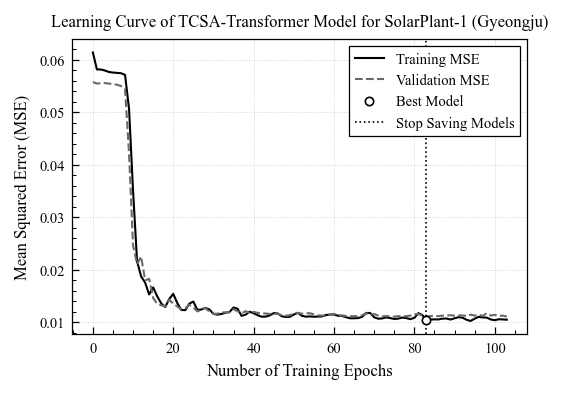

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
from Library.modelDevelopment import plot_training_validation_loss
plot_training_validation_loss(history=history, model_Name='TCSA-Transformer Model for SolarPlant-1 (Gyeongju)', patience=20)

In [ ]:
import joblib
model_Scaler = joblib.load(f"{expModelDir}scaler_Site_02.joblib")

from Library.modelDevelopment import evaluate_model
Eval_TCSA_Transformer, Predict_TCSA_Transformer = evaluate_model('TCSA-Transformer', model_TCSA_Transformer, model_Scaler, X_val, y_val)
print(Eval_TCSA_Transformer)

296/296 [==============================] - 1s 3ms/step
              Model      MAE        MSE      RMSE        R2
0  TCSA-Transformer  4.96331  99.924629  9.996231  0.784431


In [ ]:
new/test

NameError: name 'new' is not defined

# <u>Working with __PV-2__</u>

> Windowing and Splitting to Train and Validation

In [130]:
from Library.modelDevelopment import make_windows, split_train_val

X,y = make_windows(PV2_train, input_len=168, output_len=24, stride=1)
X_train, y_train, X_val, y_val = split_train_val(X, y, val_frac=0.20, gap=168+24)

print('='*50)
print("Training and Validation Set Shapes for PV2_train:")
print('-'*50)
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print('-'*50)
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_val shape: {y_val.shape}')
print('='*50)

Training and Validation Set Shapes for PV2_train:
--------------------------------------------------
X shape: (47257, 168, 7)
y shape: (47257, 24)
--------------------------------------------------
X_train shape: (37614, 168, 7)
y_train shape: (37614, 24)
X_val shape: (9451, 168, 7)
y_val shape: (9451, 24)


> __PV2:__ Training __LSTM__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = LSTM  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = LSTM  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = LSTM  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
x   = LSTM  (units= 32, return_sequences=True)(x)       # Fourth LSTM Layer
v   = GlobalAveragePooling1D()(x)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_LSTM  = Model(inputs=[inp], outputs=out)          # Define Model
model_LSTM.compile(optimizer='adam', loss='mse')        # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_LSTM.summary())                             # Summarize Model Development
plot_model(model_LSTM, to_file=f'{expFigDir}model_LSTM.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                            # Clear Previous History
    model_LSTM.compile(optimizer="Adam", loss="mse", metrics=["mae", "mse"])    # Compile Model with Metrics
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                           # Save Best Model
        f'{expModelDir}PV2_model_LSTM.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                             # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_LSTM.fit(                                               # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 168, 7)]          0         
                                                                 
 lstm (LSTM)                 (None, 168, 128)          69632     
                                                                 
 lstm_1 (LSTM)               (None, 168, 64)           49408     
                                                                 
 lstm_2 (LSTM)               (None, 168, 48)           21696     
                                                                 
 lstm_3 (LSTM)               (None, 168, 32)           10368     
                                                                 
 global_average_pooling1d (G  (None, 32)               0         
 lobalAveragePooling1D)                                          
                                                             

History saved to:
  ../Export/History/Site-02/history-LSTM Model for SolarPlant-2 (Gyeongju).pkl
  ../Export/History/Site-02/history-LSTM Model for SolarPlant-2 (Gyeongju).json


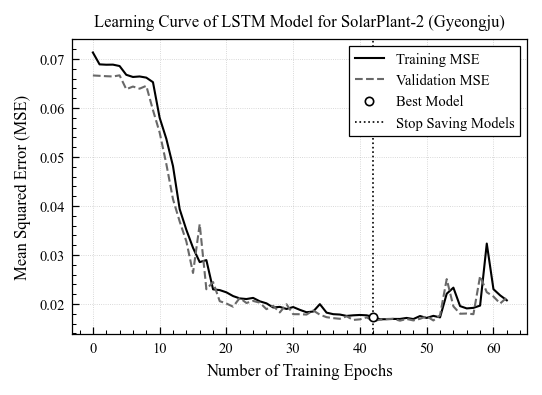

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
importlib.reload(Library.modelDevelopment)
from Library.modelDevelopment import plot_training_validation_loss
plot_training_validation_loss(history=history, model_Name='LSTM Model for SolarPlant-2 (Gyeongju)', patience=20)


In [ ]:
# Load Best Model
model_LSTM  = load_model(expModelDir + 'PV2_model_LSTM.h5')

# Evaluation and Output
import joblib
model_Scaler = joblib.load(f"{expModelDir}scaler_Site_02.joblib")

from Library.modelDevelopment import evaluate_model
Eval_LSTM, Predict_LSTM = evaluate_model('LSTM', model_LSTM, model_Scaler, X_val, y_val)
print(Eval_LSTM)

296/296 [==============================] - 5s 13ms/step
  Model       MAE         MSE       RMSE        R2
0  LSTM  6.828043  149.588699  12.230646  0.724777


> __PV2:__ Training __MHSA-LSTM__ Model

In [131]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = LSTM  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = LSTM  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = LSTM  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
x   = LSTM  (units= 32, return_sequences=True)(x)       # Fourth LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=32)([x, x])  # attention after it
# v   = Flatten()(a)                                      # Flatten the output of attention layer
v   = GlobalAveragePooling1D()(a)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_MHSA_LSTM  = Model(inputs=[inp], outputs=out)     # Define Model
model_MHSA_LSTM.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_MHSA_LSTM.summary())                        # Summarize Model Development
plot_model(model_MHSA_LSTM, to_file=f'{expFigDir}model_MHSA_LSTM.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_MHSA_LSTM.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV2_model_MHSA_LSTM.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_MHSA_LSTM.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 lstm (LSTM)                    (None, 168, 128)     69632       ['input_1[0][0]']                
                                                                                                  
 lstm_1 (LSTM)                  (None, 168, 64)      49408       ['lstm[0][0]']                   
                                                                                                  
 lstm_2 (LSTM)                  (None, 168, 48)      21696       ['lstm_1[0][0]']                 
                                                                                              

History saved to:
  ../Export/History/Site-02/history-MHSA-LSTM Model for SolarPlant-2 (Gyeongju).pkl
  ../Export/History/Site-02/history-MHSA-LSTM Model for SolarPlant-2 (Gyeongju).json


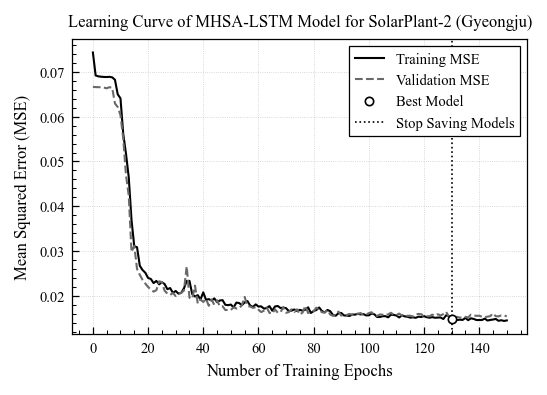

In [132]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='MHSA-LSTM Model for SolarPlant-2 (Gyeongju)', patience=20)

In [133]:
Eval_MHSA_LSTM, Predict_MHSA_LSTM = evaluate_model('MHSA-LSTM', model_MHSA_LSTM, model_Scaler, X_val, y_val)
print(Eval_MHSA_LSTM)

296/296 [==============================] - 5s 16ms/step
       Model       MAE         MSE      RMSE        R2
0  MHSA-LSTM  6.349411  139.405716  11.80702  0.743512


> __PV2:__ Training __TCSA-LSTM__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = LSTM  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = LSTM  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = LSTM  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=48)([x, x])  # attention after it
x   = LSTM  (units= 32)(a)                              # Fourth LSTM Layer
out = Dense (units= 24, activation='relu')(x)           # Output Layer
model_TCSA_LSTM  = Model(inputs=[inp], outputs=out)     # Define Model
model_TCSA_LSTM.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_TCSA_LSTM.summary())                        # Summarize Model Development
plot_model(model_TCSA_LSTM, to_file=f'{expFigDir}model_TCSA_LSTM.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_TCSA_LSTM.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV2_model_TCSA_LSTM.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_TCSA_LSTM.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 lstm (LSTM)                    (None, 168, 128)     69632       ['input_1[0][0]']                
                                                                                                  
 lstm_1 (LSTM)                  (None, 168, 64)      49408       ['lstm[0][0]']                   
                                                                                                  
 lstm_2 (LSTM)                  (None, 168, 48)      21696       ['lstm_1[0][0]']                 
                                                                                              

History saved to:
  ../Export/History/Site-02/history-TCSA-LSTM Model for SolarPlant-2 (Gyeongju).pkl
  ../Export/History/Site-02/history-TCSA-LSTM Model for SolarPlant-2 (Gyeongju).json


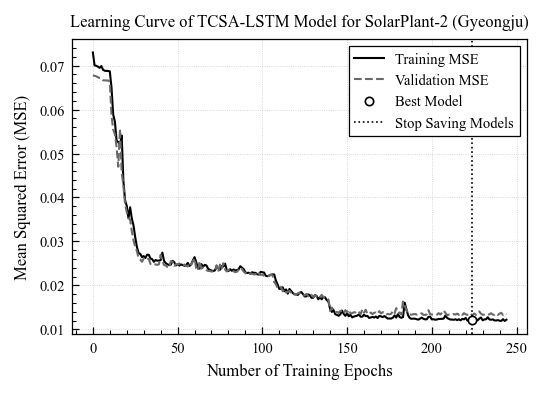

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='TCSA-LSTM Model for SolarPlant-2 (Gyeongju)', patience=20)

In [ ]:
Eval_TCSA_LSTM, Predict_TCSA_LSTM = evaluate_model('TCSA-LSTM', model_TCSA_LSTM, model_Scaler, X_val, y_val)
print(Eval_TCSA_LSTM)

296/296 [==============================] - 6s 17ms/step
       Model       MAE         MSE       RMSE        R2
0  TCSA-LSTM  5.678319  121.373802  11.016978  0.776688


> __PV2:__ Training __GRU__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = GRU  (units=128, return_sequences=True)(inp)      # First GRU Layer
x   = GRU  (units= 64, return_sequences=True)(x)        # Second GRU Layer
x   = GRU  (units= 48, return_sequences=True)(x)        # Third GRU Layer
x   = GRU  (units= 32, return_sequences=True)(x)        # Fourth GRU Layer
v   = GlobalAveragePooling1D()(x)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_GRU  = Model(inputs=[inp], outputs=out)           # Define Model
model_GRU.compile(optimizer='adam', loss='mse')         # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_GRU.summary())                              # Summarize Model Development
plot_model(model_GRU, to_file=f'{expFigDir}model_GRU.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                            # Clear Previous History
    model_GRU.compile(optimizer="Adam", loss="mse", metrics=["mae", "mse"])     # Compile Model with Metrics
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                           # Save Best Model
        f'{expModelDir}PV2_model_GRU.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                             # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_GRU.fit(                                                # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 168, 7)]          0         
                                                                 
 gru (GRU)                   (None, 168, 128)          52608     
                                                                 
 gru_1 (GRU)                 (None, 168, 64)           37248     
                                                                 
 gru_2 (GRU)                 (None, 168, 48)           16416     
                                                                 
 gru_3 (GRU)                 (None, 168, 32)           7872      
                                                                 
 global_average_pooling1d (G  (None, 32)               0         
 lobalAveragePooling1D)                                          
                                                             

History saved to:
  ../Export/History/Site-02/history-GRU Model for SolarPlant-2 (Gyeongju).pkl
  ../Export/History/Site-02/history-GRU Model for SolarPlant-2 (Gyeongju).json


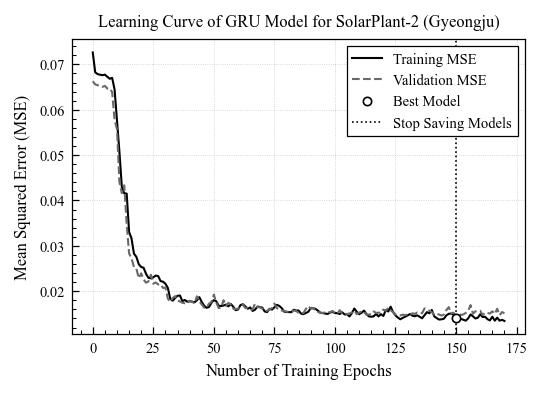

In [ ]:
plot_training_validation_loss(history=history, model_Name='GRU Model for SolarPlant-2 (Gyeongju)', patience=20)

In [ ]:
Eval_GRU, Predict_GRU = evaluate_model('GRU', model_GRU, model_Scaler, X_val, y_val)
print(Eval_GRU)

296/296 [==============================] - 5s 14ms/step
  Model       MAE         MSE       RMSE        R2
0   GRU  6.308252  136.906296  11.700696  0.748111


> __PV2:__ Training __MHSA-GRU__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = GRU  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = GRU  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = GRU  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
x   = GRU  (units= 32, return_sequences=True)(x)       # Fourth LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=32)([x, x])  # attention after it
# v   = Flatten()(a)                                      # Flatten the output of attention layer
v   = GlobalAveragePooling1D()(a)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_MHSA_GRU  = Model(inputs=[inp], outputs=out)     # Define Model
model_MHSA_GRU.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_MHSA_GRU.summary())                        # Summarize Model Development
plot_model(model_MHSA_GRU, to_file=f'{expFigDir}model_MHSA_GRU.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_MHSA_GRU.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV2_model_MHSA_GRU.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_MHSA_GRU.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 gru (GRU)                      (None, 168, 128)     52608       ['input_1[0][0]']                
                                                                                                  
 gru_1 (GRU)                    (None, 168, 64)      37248       ['gru[0][0]']                    
                                                                                                  
 gru_2 (GRU)                    (None, 168, 48)      16416       ['gru_1[0][0]']                  
                                                                                              

History saved to:
  ../Export/History/Site-02/history-MHSA-GRU Model for SolarPlant-2 (Gyeongju).pkl
  ../Export/History/Site-02/history-MHSA-GRU Model for SolarPlant-2 (Gyeongju).json


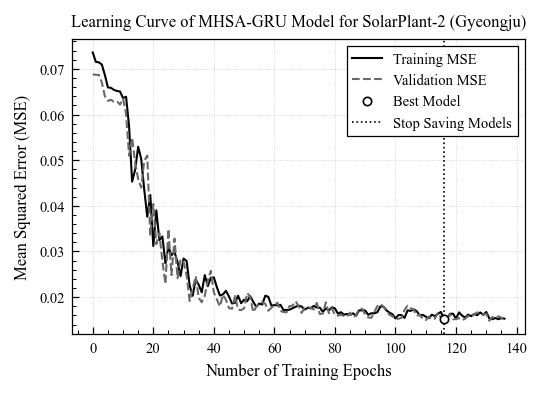

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='MHSA-GRU Model for SolarPlant-2 (Gyeongju)', patience=20)

In [ ]:
Eval_MHSA_GRU, Predict_MHSA_GRU = evaluate_model('MHSA-GRU', model_MHSA_GRU, model_Scaler, X_val, y_val)
print(Eval_MHSA_GRU)

296/296 [==============================] - 6s 17ms/step
      Model       MAE        MSE       RMSE        R2
0  MHSA-GRU  6.405839  134.63028  11.603029  0.752298


In [ ]:
# 296/296 [==============================] - 4s 12ms/step
#       Model       MAE         MSE       RMSE        R2
# 0  MHSA-GRU  7.276356  161.071503  12.691395  0.702364

> __PV2:__ Training __TCSA-GRU__ Model

In [134]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = GRU  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = GRU  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = GRU  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=48)([x, x])  # attention after it
x   = GRU  (units= 32)(a)                              # Fourth LSTM Layer
out = Dense (units= 24, activation='relu')(x)           # Output Layer
model_TCSA_GRU  = Model(inputs=[inp], outputs=out)     # Define Model
model_TCSA_GRU.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_TCSA_GRU.summary())                        # Summarize Model Development
plot_model(model_TCSA_GRU, to_file=f'{expFigDir}model_TCSA_GRU.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_TCSA_GRU.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV2_model_TCSA_GRU.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_TCSA_GRU.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 gru (GRU)                      (None, 168, 128)     52608       ['input_1[0][0]']                
                                                                                                  
 gru_1 (GRU)                    (None, 168, 64)      37248       ['gru[0][0]']                    
                                                                                                  
 gru_2 (GRU)                    (None, 168, 48)      16416       ['gru_1[0][0]']                  
                                                                                              

History saved to:
  ../Export/History/Site-02/history-TCSA-GRU Model for SolarPlant-2 (Gyeongju).pkl
  ../Export/History/Site-02/history-TCSA-GRU Model for SolarPlant-2 (Gyeongju).json


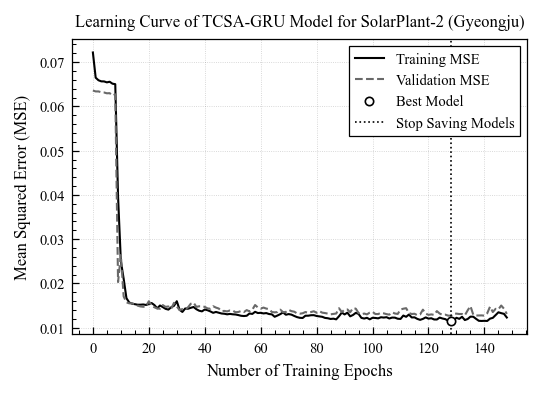

In [135]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='TCSA-GRU Model for SolarPlant-2 (Gyeongju)', patience=20)

In [136]:
Eval_TCSA_GRU, Predict_TCSA_GRU = evaluate_model('TCSA-GRU', model_TCSA_GRU, model_Scaler, X_val, y_val)
print(Eval_TCSA_GRU)

296/296 [==============================] - 4s 13ms/step
      Model       MAE         MSE       RMSE        R2
0  TCSA-GRU  5.712253  118.550407  10.888086  0.781883


> __PV2:__ Training __MHSA-Transformer__ Model

In [ ]:
import numpy as np                                       # needed for positional encoding

# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- Positional Encoding Layer (fixed sinusoidal) -----
class PositionalEncoding(tf.keras.layers.Layer):        # adds timestep order to embeddings
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        pos   = np.arange(seq_len)[:, None]
        i     = np.arange(d_model)[None, :]
        angle = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        pe              = np.zeros((seq_len, d_model), dtype=np.float32)
        pe[:, 0::2]     = np.sin(angle[:, 0::2])
        pe[:, 1::2]     = np.cos(angle[:, 1::2])
        self.pe         = tf.constant(pe[None, ...])    # (1, seq_len, d_model)
    def call(self, x):
        return x + self.pe                              # inject positions
    def get_config(self):
        return super().get_config()

# ----- Transformer Encoder Block -----
def transformer_encoder(x, head_size, num_heads, ff_dim):
    a    = MultiHeadAttention(num_heads=num_heads, head_size=head_size)([x, x]) # Self-Attention
    ff   = Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(a)          # Feed-Forward Network
    ff   = Conv1D(filters=x.shape[-1], kernel_size=1)(ff)                       # Project back to input dimension
    return ff

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                                             # Define the input
x   = Dense(32)(inp)                                                    # project 7 features -> model dim
x   = PositionalEncoding(seq_len=168, d_model=32)(x)                    # add timestep order
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # First Encoder Block
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # Second Encoder Block
v   = GlobalAveragePooling1D()(x)                                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)                           # Output Layer
model_MHSA_Transformer = Model(inputs=[inp], outputs=out)               # Define Model
model_MHSA_Transformer.compile(optimizer='adam', loss='mse')            # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_MHSA_Transformer.summary())                                 # Summarize Model Development
plot_model(model_MHSA_Transformer, to_file=f'{expFigDir}model_MHSA_Transformer.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                    # Clear Previous History
    model_MHSA_Transformer.compile(                                     # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                   # Save Best Model
        f'{expModelDir}PV2_model_MHSA_Transformer.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_MHSA_Transformer.fit(                           # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024,
        validation_data=(X_val, y_val), verbose=1,
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 dense (Dense)                  (None, 168, 32)      256         ['input_1[0][0]']                
                                                                                                  
 positional_encoding (Positiona  (None, 168, 32)     0           ['dense[0][0]']                  
 lEncoding)                                                                                       
                                                                                                  
 multi_head_attention (MultiHea  (None, 168, 32)     49184       ['positional_encoding[0][0]',

In [ ]:
# model_MHSA_Transformer = load_model(f'{expModelDir}PV2_model_MHSA_Transformer.h5',
#                                     custom_objects={'PositionalEncoding': PositionalEncoding})

History saved to:
  ../Export/History/Site-02/history-MHSA-Transformer Model for SolarPlant-2 (Gyeongju).pkl
  ../Export/History/Site-02/history-MHSA-Transformer Model for SolarPlant-2 (Gyeongju).json


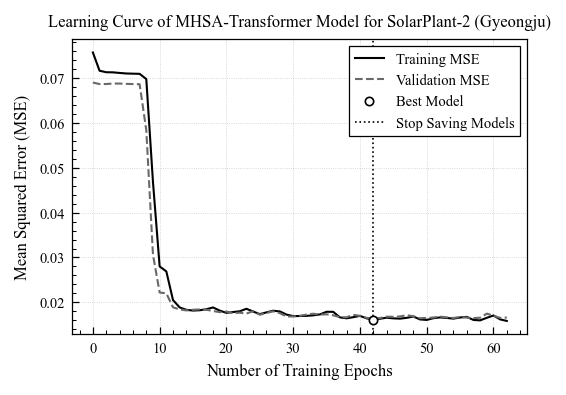

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
from Library.modelDevelopment import plot_training_validation_loss
plot_training_validation_loss(history=history, model_Name='MHSA-Transformer Model for SolarPlant-2 (Gyeongju)', patience=20)

In [ ]:
import joblib
model_Scaler = joblib.load(f"{expModelDir}scaler_Site_02.joblib")

from Library.modelDevelopment import evaluate_model
Eval_MHSA_Transformer, Predict_MHSA_Transformer = evaluate_model('MHSA-Transformer', model_MHSA_Transformer, model_Scaler, X_val, y_val)
print(Eval_MHSA_Transformer)

296/296 [==============================] - 1s 2ms/step
              Model       MAE        MSE       RMSE        R2
0  MHSA-Transformer  6.282252  150.12088  12.252383  0.723798


> __PV2:__ Training __TCSA-Transformer__ Model

In [ ]:
import numpy as np                                       # needed for positional encoding

# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- Positional Encoding Layer (fixed sinusoidal) -----
class PositionalEncoding(tf.keras.layers.Layer):        # adds timestep order to embeddings
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        pos   = np.arange(seq_len)[:, None]
        i     = np.arange(d_model)[None, :]
        angle = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        pe              = np.zeros((seq_len, d_model), dtype=np.float32)
        pe[:, 0::2]     = np.sin(angle[:, 0::2])
        pe[:, 1::2]     = np.cos(angle[:, 1::2])
        self.pe         = tf.constant(pe[None, ...])    # (1, seq_len, d_model)
    def call(self, x):
        return x + self.pe                              # inject positions
    def get_config(self):
        return super().get_config()

# ----- Transformer Encoder Block -----
def transformer_encoder(x, head_size, num_heads, ff_dim):
    a    = MultiHeadAttention(num_heads=num_heads, head_size=head_size)([x, x]) # Self-Attention
    ff   = Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(a)          # Feed-Forward Network
    ff   = Conv1D(filters=x.shape[-1], kernel_size=1)(ff)                       # Project back to input dimension
    return ff

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                                             # Define the input
x   = Dense(32)(inp)                                                    # project 7 features -> model dim
x   = PositionalEncoding(seq_len=168, d_model=32)(x)                    # add timestep order
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # First Encoder Block
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # Second Encoder Block
a   = MultiHeadAttention(num_heads=12, head_size=32)([x, x])            # TCSA
v   = GlobalAveragePooling1D()(a)                                       # Global Average Pooling 
out = Dense (units= 24, activation='relu')(v)                           # Output Layer
model_TCSA_Transformer = Model(inputs=[inp], outputs=out)               # Define Model
model_TCSA_Transformer.compile(optimizer='adam', loss='mse')            # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_TCSA_Transformer.summary())                                 # Summarize Model Development
plot_model(model_TCSA_Transformer, to_file=f'{expFigDir}model_TCSA_Transformer.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                    # Clear Previous History
    model_TCSA_Transformer.compile(                                     # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                   # Save Best Model
        f'{expModelDir}PV2_model_TCSA_Transformer.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_TCSA_Transformer.fit(                           # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024,
        validation_data=(X_val, y_val), verbose=1,
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 dense (Dense)                  (None, 168, 32)      256         ['input_1[0][0]']                
                                                                                                  
 positional_encoding (Positiona  (None, 168, 32)     0           ['dense[0][0]']                  
 lEncoding)                                                                                       
                                                                                                  
 multi_head_attention (MultiHea  (None, 168, 32)     49184       ['positional_encoding[0][0]',

In [ ]:
# model_TCSA_Transformer = load_model(f'{expModelDir}PV2_model_TCSA_Transformer.h5',
#                                     custom_objects={'PositionalEncoding': PositionalEncoding})

History saved to:
  ../Export/History/Site-02/history-TCSA-Transformer Model for SolarPlant-2 (Gyeongju).pkl
  ../Export/History/Site-02/history-TCSA-Transformer Model for SolarPlant-2 (Gyeongju).json


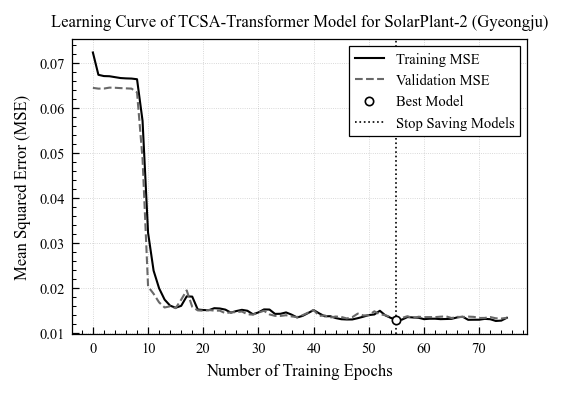

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
from Library.modelDevelopment import plot_training_validation_loss
plot_training_validation_loss(history=history, model_Name='TCSA-Transformer Model for SolarPlant-2 (Gyeongju)', patience=20)

In [ ]:
import joblib
model_Scaler = joblib.load(f"{expModelDir}scaler_Site_02.joblib")

from Library.modelDevelopment import evaluate_model
Eval_TCSA_Transformer, Predict_TCSA_Transformer = evaluate_model('TCSA-Transformer', model_TCSA_Transformer, model_Scaler, X_val, y_val)
print(Eval_TCSA_Transformer)

296/296 [==============================] - 1s 3ms/step
              Model       MAE         MSE       RMSE        R2
0  TCSA-Transformer  5.784701  121.928833  11.042139  0.775667


# <u>Working with __PV-3__</u>

> Windowing and Splitting to Train and Validation

In [137]:
from Library.modelDevelopment import make_windows, split_train_val

X,y = make_windows(PV3_train, input_len=168, output_len=24, stride=1)
X_train, y_train, X_val, y_val = split_train_val(X, y, val_frac=0.20, gap=168+24)

print('='*50)
print("Training and Validation Set Shapes for PV3_train:")
print('-'*50)
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print('-'*50)
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_val shape: {y_val.shape}')
print('='*50)

Training and Validation Set Shapes for PV3_train:
--------------------------------------------------
X shape: (47257, 168, 7)
y shape: (47257, 24)
--------------------------------------------------
X_train shape: (37614, 168, 7)
y_train shape: (37614, 24)
X_val shape: (9451, 168, 7)
y_val shape: (9451, 24)


> __PV3:__ Training __LSTM__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = LSTM  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = LSTM  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = LSTM  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
x   = LSTM  (units= 32, return_sequences=True)(x)       # Fourth LSTM Layer
v   = GlobalAveragePooling1D()(x)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_LSTM  = Model(inputs=[inp], outputs=out)          # Define Model
model_LSTM.compile(optimizer='adam', loss='mse')        # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_LSTM.summary())                             # Summarize Model Development
plot_model(model_LSTM, to_file=f'{expFigDir}model_LSTM.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                            # Clear Previous History
    model_LSTM.compile(optimizer="Adam", loss="mse", metrics=["mae", "mse"])    # Compile Model with Metrics
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                           # Save Best Model
        f'{expModelDir}PV3_model_LSTM.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                             # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_LSTM.fit(                                               # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 168, 7)]          0         
                                                                 
 lstm (LSTM)                 (None, 168, 128)          69632     
                                                                 
 lstm_1 (LSTM)               (None, 168, 64)           49408     
                                                                 
 lstm_2 (LSTM)               (None, 168, 48)           21696     
                                                                 
 lstm_3 (LSTM)               (None, 168, 32)           10368     
                                                                 
 global_average_pooling1d (G  (None, 32)               0         
 lobalAveragePooling1D)                                          
                                                             

History saved to:
  ../Export/History/Site-02/history-LSTM Model for SolarPlant-3 (Gyeongju).pkl
  ../Export/History/Site-02/history-LSTM Model for SolarPlant-3 (Gyeongju).json


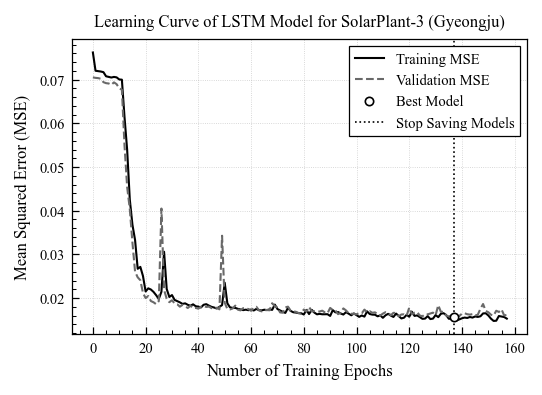

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
importlib.reload(Library.modelDevelopment)
from Library.modelDevelopment import plot_training_validation_loss
plot_training_validation_loss(history=history, model_Name='LSTM Model for SolarPlant-3 (Gyeongju)', patience=20)

In [ ]:
# Load Best Model
model_LSTM  = load_model(expModelDir + 'PV3_model_LSTM.h5')

# Evaluation and Output
import joblib
model_Scaler = joblib.load(f"{expModelDir}scaler_Site_02.joblib")

from Library.modelDevelopment import evaluate_model
Eval_LSTM, Predict_LSTM = evaluate_model('LSTM', model_LSTM, model_Scaler, X_val, y_val)
print(Eval_LSTM)

296/296 [==============================] - 4s 12ms/step
  Model       MAE         MSE       RMSE        R2
0  LSTM  6.538917  142.428299  11.934333  0.759948


> __PV3:__ Training __MHSA-LSTM__ Model

In [138]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = LSTM  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = LSTM  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = LSTM  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
x   = LSTM  (units= 32, return_sequences=True)(x)       # Fourth LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=32)([x, x])  # attention after it
# v   = Flatten()(a)                                      # Flatten the output of attention layer
v   = GlobalAveragePooling1D()(a)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_MHSA_LSTM  = Model(inputs=[inp], outputs=out)     # Define Model
model_MHSA_LSTM.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_MHSA_LSTM.summary())                        # Summarize Model Development
plot_model(model_MHSA_LSTM, to_file=f'{expFigDir}model_MHSA_LSTM.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_MHSA_LSTM.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV3_model_MHSA_LSTM.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_MHSA_LSTM.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 lstm (LSTM)                    (None, 168, 128)     69632       ['input_1[0][0]']                
                                                                                                  
 lstm_1 (LSTM)                  (None, 168, 64)      49408       ['lstm[0][0]']                   
                                                                                                  
 lstm_2 (LSTM)                  (None, 168, 48)      21696       ['lstm_1[0][0]']                 
                                                                                              

History saved to:
  ../Export/History/Site-02/history-MHSA-LSTM Model for SolarPlant-3 (Gyeongju).pkl
  ../Export/History/Site-02/history-MHSA-LSTM Model for SolarPlant-3 (Gyeongju).json


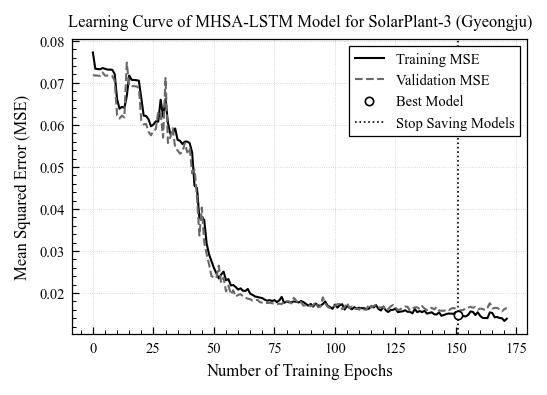

In [139]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='MHSA-LSTM Model for SolarPlant-3 (Gyeongju)', patience=20)

In [140]:
Eval_MHSA_LSTM, Predict_MHSA_LSTM = evaluate_model('MHSA-LSTM', model_MHSA_LSTM, model_Scaler, X_val, y_val)
print(Eval_MHSA_LSTM)

296/296 [==============================] - 4s 12ms/step
       Model       MAE         MSE       RMSE        R2
0  MHSA-LSTM  6.498831  149.130341  12.211893  0.748652


> __PV3:__ Training __TCSA-LSTM__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = LSTM  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = LSTM  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = LSTM  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=48)([x, x])  # attention after it
x   = LSTM  (units= 32)(a)                              # Fourth LSTM Layer
out = Dense (units= 24, activation='relu')(x)           # Output Layer
model_TCSA_LSTM  = Model(inputs=[inp], outputs=out)     # Define Model
model_TCSA_LSTM.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_TCSA_LSTM.summary())                        # Summarize Model Development
plot_model(model_TCSA_LSTM, to_file=f'{expFigDir}model_TCSA_LSTM.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_TCSA_LSTM.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV3_model_TCSA_LSTM.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_TCSA_LSTM.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 lstm (LSTM)                    (None, 168, 128)     69632       ['input_1[0][0]']                
                                                                                                  
 lstm_1 (LSTM)                  (None, 168, 64)      49408       ['lstm[0][0]']                   
                                                                                                  
 lstm_2 (LSTM)                  (None, 168, 48)      21696       ['lstm_1[0][0]']                 
                                                                                              

History saved to:
  ../Export/History/Site-02/history-TCSA-LSTM Model for SolarPlant-3 (Gyeongju).pkl
  ../Export/History/Site-02/history-TCSA-LSTM Model for SolarPlant-3 (Gyeongju).json


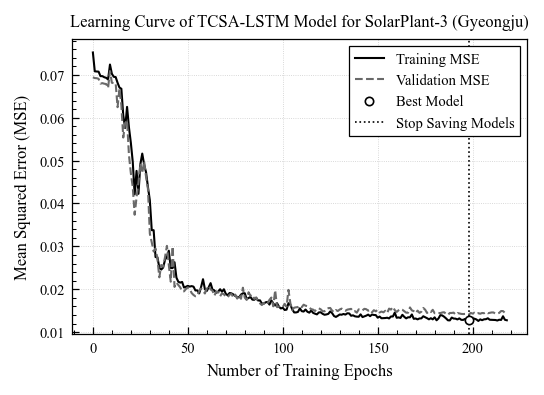

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='TCSA-LSTM Model for SolarPlant-3 (Gyeongju)', patience=20)

In [ ]:
Eval_TCSA_LSTM, Predict_TCSA_LSTM = evaluate_model('TCSA-LSTM', model_TCSA_LSTM, model_Scaler, X_val, y_val)
print(Eval_TCSA_LSTM)

296/296 [==============================] - 5s 16ms/step
       Model      MAE         MSE       RMSE        R2
0  TCSA-LSTM  5.81558  129.867126  11.395926  0.781119


> __PV3:__ Training __GRU__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = GRU  (units=128, return_sequences=True)(inp)      # First GRU Layer
x   = GRU  (units= 64, return_sequences=True)(x)        # Second GRU Layer
x   = GRU  (units= 48, return_sequences=True)(x)        # Third GRU Layer
x   = GRU  (units= 32, return_sequences=True)(x)        # Fourth GRU Layer
v   = GlobalAveragePooling1D()(x)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_GRU  = Model(inputs=[inp], outputs=out)           # Define Model
model_GRU.compile(optimizer='adam', loss='mse')         # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_GRU.summary())                              # Summarize Model Development
plot_model(model_GRU, to_file=f'{expFigDir}model_GRU.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                            # Clear Previous History
    model_GRU.compile(optimizer="Adam", loss="mse", metrics=["mae", "mse"])     # Compile Model with Metrics
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                           # Save Best Model
        f'{expModelDir}PV3_model_GRU.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                             # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_GRU.fit(                                                # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 168, 7)]          0         
                                                                 
 gru (GRU)                   (None, 168, 128)          52608     
                                                                 
 gru_1 (GRU)                 (None, 168, 64)           37248     
                                                                 
 gru_2 (GRU)                 (None, 168, 48)           16416     
                                                                 
 gru_3 (GRU)                 (None, 168, 32)           7872      
                                                                 
 global_average_pooling1d (G  (None, 32)               0         
 lobalAveragePooling1D)                                          
                                                             

History saved to:
  ../Export/History/Site-02/history-GRU Model for SolarPlant-3 (Gyeongju).pkl
  ../Export/History/Site-02/history-GRU Model for SolarPlant-3 (Gyeongju).json


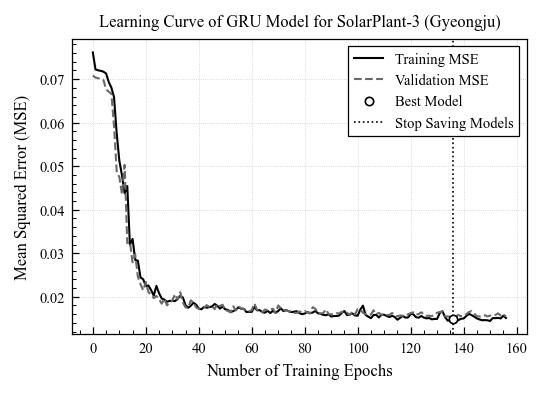

In [ ]:
plot_training_validation_loss(history=history, model_Name='GRU Model for SolarPlant-3 (Gyeongju)', patience=20)

In [ ]:
Eval_GRU, Predict_GRU = evaluate_model('GRU', model_GRU, model_Scaler, X_val, y_val)
print(Eval_GRU)

296/296 [==============================] - 5s 15ms/step
  Model       MAE        MSE       RMSE        R2
0   GRU  6.328606  140.00267  11.832272  0.764036


> __PV3:__ Training __MHSA-GRU__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = GRU  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = GRU  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = GRU  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
x   = GRU  (units= 32, return_sequences=True)(x)       # Fourth LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=32)([x, x])  # attention after it
# v   = Flatten()(a)                                      # Flatten the output of attention layer
v   = GlobalAveragePooling1D()(a)                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)           # Output Layer
model_MHSA_GRU  = Model(inputs=[inp], outputs=out)     # Define Model
model_MHSA_GRU.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_MHSA_GRU.summary())                        # Summarize Model Development
plot_model(model_MHSA_GRU, to_file=f'{expFigDir}model_MHSA_GRU.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_MHSA_GRU.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV3_model_MHSA_GRU.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_MHSA_GRU.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 gru (GRU)                      (None, 168, 128)     52608       ['input_1[0][0]']                
                                                                                                  
 gru_1 (GRU)                    (None, 168, 64)      37248       ['gru[0][0]']                    
                                                                                                  
 gru_2 (GRU)                    (None, 168, 48)      16416       ['gru_1[0][0]']                  
                                                                                              

History saved to:
  ../Export/History/Site-02/history-MHSA-GRU Model for SolarPlant-3 (Gyeongju).pkl
  ../Export/History/Site-02/history-MHSA-GRU Model for SolarPlant-3 (Gyeongju).json


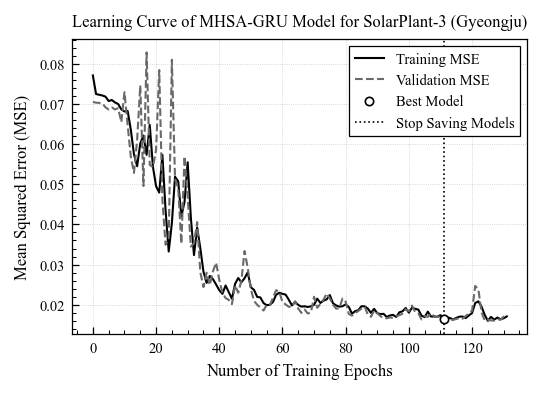

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='MHSA-GRU Model for SolarPlant-3 (Gyeongju)', patience=20)

In [ ]:
Eval_MHSA_GRU, Predict_MHSA_GRU = evaluate_model('MHSA-GRU', model_MHSA_GRU, model_Scaler, X_val, y_val)
print(Eval_MHSA_GRU)

296/296 [==============================] - 5s 15ms/step
      Model       MAE         MSE       RMSE        R2
0  MHSA-GRU  6.827137  150.902512  12.284238  0.745665


> __PV3:__ Training __TCSA-GRU__ Model

In [ ]:
# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                             # Define the input
x   = GRU  (units=128, return_sequences=True)(inp)     # First LSTM Layer
x   = GRU  (units= 64, return_sequences=True)(x)       # Second LSTM Layer
x   = GRU  (units= 48, return_sequences=True)(x)       # Third LSTM Layer
a   = MultiHeadAttention(num_heads=12, head_size=48)([x, x])  # attention after it
x   = GRU  (units= 32)(a)                              # Fourth LSTM Layer
out = Dense (units= 24, activation='relu')(x)           # Output Layer
model_TCSA_GRU  = Model(inputs=[inp], outputs=out)     # Define Model
model_TCSA_GRU.compile(optimizer='adam', loss='mse')   # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_TCSA_GRU.summary())                        # Summarize Model Development
plot_model(model_TCSA_GRU, to_file=f'{expFigDir}model_TCSA_GRU.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                    # Clear Previous History
    model_TCSA_GRU.compile(                            # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])    
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(   # Save Best Model
        f'{expModelDir}PV3_model_TCSA_GRU.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_TCSA_GRU.fit(                  # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024, 
        validation_data=(X_val, y_val), verbose=1, 
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 gru (GRU)                      (None, 168, 128)     52608       ['input_1[0][0]']                
                                                                                                  
 gru_1 (GRU)                    (None, 168, 64)      37248       ['gru[0][0]']                    
                                                                                                  
 gru_2 (GRU)                    (None, 168, 48)      16416       ['gru_1[0][0]']                  
                                                                                              

History saved to:
  ../Export/History/Site-02/history-TCSA-GRU Model for SolarPlant-3 (Gyeongju).pkl
  ../Export/History/Site-02/history-TCSA-GRU Model for SolarPlant-3 (Gyeongju).json


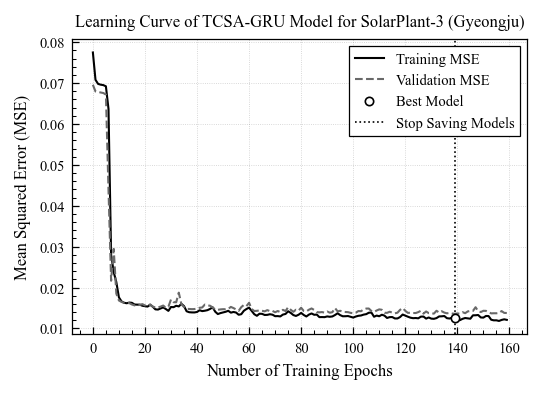

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
plot_training_validation_loss(history=history, model_Name='TCSA-GRU Model for SolarPlant-3 (Gyeongju)', patience=20)

In [ ]:
Eval_TCSA_GRU, Predict_TCSA_GRU = evaluate_model('TCSA-GRU', model_TCSA_GRU, model_Scaler, X_val, y_val)
print(Eval_TCSA_GRU)

296/296 [==============================] - 5s 15ms/step
      Model       MAE         MSE       RMSE        R2
0  TCSA-GRU  5.698671  124.659607  11.165107  0.789896


> __PV3:__ Training __MHSA-Transformer__ Model

In [ ]:
import numpy as np                                       # needed for positional encoding

# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- Positional Encoding Layer (fixed sinusoidal) -----
class PositionalEncoding(tf.keras.layers.Layer):        # adds timestep order to embeddings
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        pos   = np.arange(seq_len)[:, None]
        i     = np.arange(d_model)[None, :]
        angle = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        pe              = np.zeros((seq_len, d_model), dtype=np.float32)
        pe[:, 0::2]     = np.sin(angle[:, 0::2])
        pe[:, 1::2]     = np.cos(angle[:, 1::2])
        self.pe         = tf.constant(pe[None, ...])    # (1, seq_len, d_model)
    def call(self, x):
        return x + self.pe                              # inject positions
    def get_config(self):
        return super().get_config()

# ----- Transformer Encoder Block -----
def transformer_encoder(x, head_size, num_heads, ff_dim):
    a    = MultiHeadAttention(num_heads=num_heads, head_size=head_size)([x, x]) # Self-Attention
    ff   = Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(a)          # Feed-Forward Network
    ff   = Conv1D(filters=x.shape[-1], kernel_size=1)(ff)                       # Project back to input dimension
    return ff

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                                             # Define the input
x   = Dense(32)(inp)                                                    # project 7 features -> model dim
x   = PositionalEncoding(seq_len=168, d_model=32)(x)                    # add timestep order
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # First Encoder Block
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # Second Encoder Block
v   = GlobalAveragePooling1D()(x)                                       # Global Average Pooling
out = Dense (units= 24, activation='relu')(v)                           # Output Layer
model_MHSA_Transformer = Model(inputs=[inp], outputs=out)               # Define Model
model_MHSA_Transformer.compile(optimizer='adam', loss='mse')            # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_MHSA_Transformer.summary())                                 # Summarize Model Development
plot_model(model_MHSA_Transformer, to_file=f'{expFigDir}model_MHSA_Transformer.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                    # Clear Previous History
    model_MHSA_Transformer.compile(                                     # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                   # Save Best Model
        f'{expModelDir}PV3_model_MHSA_Transformer.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_MHSA_Transformer.fit(                           # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024,
        validation_data=(X_val, y_val), verbose=1,
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 dense (Dense)                  (None, 168, 32)      256         ['input_1[0][0]']                
                                                                                                  
 positional_encoding (Positiona  (None, 168, 32)     0           ['dense[0][0]']                  
 lEncoding)                                                                                       
                                                                                                  
 multi_head_attention (MultiHea  (None, 168, 32)     49184       ['positional_encoding[0][0]',

In [ ]:
# model_MHSA_Transformer = load_model(f'{expModelDir}PV3_model_MHSA_Transformer.h5',
#                                     custom_objects={'PositionalEncoding': PositionalEncoding})

History saved to:
  ../Export/History/Site-02/history-MHSA-Transformer Model for SolarPlant-3 (Gyeongju).pkl
  ../Export/History/Site-02/history-MHSA-Transformer Model for SolarPlant-3 (Gyeongju).json


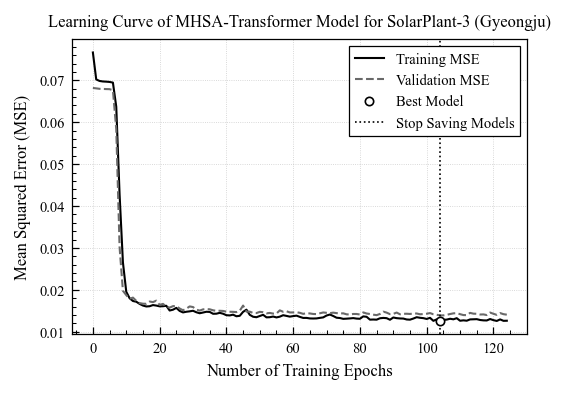

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
from Library.modelDevelopment import plot_training_validation_loss
plot_training_validation_loss(history=history, model_Name='MHSA-Transformer Model for SolarPlant-3 (Gyeongju)', patience=20)

In [ ]:
import joblib
model_Scaler = joblib.load(f"{expModelDir}scaler_Site_02.joblib")

from Library.modelDevelopment import evaluate_model
Eval_MHSA_Transformer, Predict_MHSA_Transformer = evaluate_model('MHSA-Transformer', model_MHSA_Transformer, model_Scaler, X_val, y_val)
print(Eval_MHSA_Transformer)

296/296 [==============================] - 1s 2ms/step
              Model       MAE         MSE       RMSE       R2
0  MHSA-Transformer  5.911576  127.368423  11.285762  0.78533


> __PV3:__ Training __TCSA-Transformer__ Model

In [ ]:
import numpy as np                                       # needed for positional encoding

# ----- Clear Previous History -----
backend.clear_session()                                 # Clear Previous History

# ----- Positional Encoding Layer (fixed sinusoidal) -----
class PositionalEncoding(tf.keras.layers.Layer):        # adds timestep order to embeddings
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        pos   = np.arange(seq_len)[:, None]
        i     = np.arange(d_model)[None, :]
        angle = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        pe              = np.zeros((seq_len, d_model), dtype=np.float32)
        pe[:, 0::2]     = np.sin(angle[:, 0::2])
        pe[:, 1::2]     = np.cos(angle[:, 1::2])
        self.pe         = tf.constant(pe[None, ...])    # (1, seq_len, d_model)
    def call(self, x):
        return x + self.pe                              # inject positions
    def get_config(self):
        return super().get_config()

# ----- Transformer Encoder Block -----
def transformer_encoder(x, head_size, num_heads, ff_dim):
    a    = MultiHeadAttention(num_heads=num_heads, head_size=head_size)([x, x]) # Self-Attention
    ff   = Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(a)          # Feed-Forward Network
    ff   = Conv1D(filters=x.shape[-1], kernel_size=1)(ff)                       # Project back to input dimension
    return ff

# ----- MLS-DL Model Development -----
inp = Input (shape=(168,7))                                             # Define the input
x   = Dense(32)(inp)                                                    # project 7 features -> model dim
x   = PositionalEncoding(seq_len=168, d_model=32)(x)                    # add timestep order
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # First Encoder Block
x   = transformer_encoder(x, head_size= 32, num_heads=12, ff_dim= 128)  # Second Encoder Block
a   = MultiHeadAttention(num_heads=12, head_size=32)([x, x])            # TCSA
v   = GlobalAveragePooling1D()(a)                                       # Global Average Pooling 
out = Dense (units= 24, activation='relu')(v)                           # Output Layer
model_TCSA_Transformer = Model(inputs=[inp], outputs=out)               # Define Model
model_TCSA_Transformer.compile(optimizer='adam', loss='mse')            # Compile Model

# ----- Review Model Summary and Plot Graph -----
print(model_TCSA_Transformer.summary())                                 # Summarize Model Development
plot_model(model_TCSA_Transformer, to_file=f'{expFigDir}model_TCSA_Transformer.png',show_shapes=True)   # Plot Model Graph

# ----- Train Model with GPU -----
with tf.device(selectedGPU):
    tf.keras.backend.clear_session()                                    # Clear Previous History
    model_TCSA_Transformer.compile(                                     # Compile Model with Metrics
        optimizer="Adam", loss="mse", metrics=["mae", "mse"])
    checkpoint  = tf.keras.callbacks.ModelCheckpoint(                   # Save Best Model
        f'{expModelDir}PV3_model_TCSA_Transformer.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    early_stop  = tf.keras.callbacks.EarlyStopping(                     # Terminate Training Early if No Improvement
        monitor='val_loss', patience=20)
    history     = model_TCSA_Transformer.fit(                           # Fit Model to Training Data
        X_train, y_train, epochs=1000, batch_size=1024,
        validation_data=(X_val, y_val), verbose=1,
        shuffle=False, callbacks=[checkpoint, early_stop])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 168, 7)]     0           []                               
                                                                                                  
 dense (Dense)                  (None, 168, 32)      256         ['input_1[0][0]']                
                                                                                                  
 positional_encoding (Positiona  (None, 168, 32)     0           ['dense[0][0]']                  
 lEncoding)                                                                                       
                                                                                                  
 multi_head_attention (MultiHea  (None, 168, 32)     49184       ['positional_encoding[0][0]',

In [ ]:
# model_TCSA_Transformer = load_model(f'{expModelDir}PV3_model_TCSA_Transformer.h5',
#                                     custom_objects={'PositionalEncoding': PositionalEncoding})

History saved to:
  ../Export/History/Site-02/history-TCSA-Transformer Model for SolarPlant-3 (Gyeongju).pkl
  ../Export/History/Site-02/history-TCSA-Transformer Model for SolarPlant-3 (Gyeongju).json


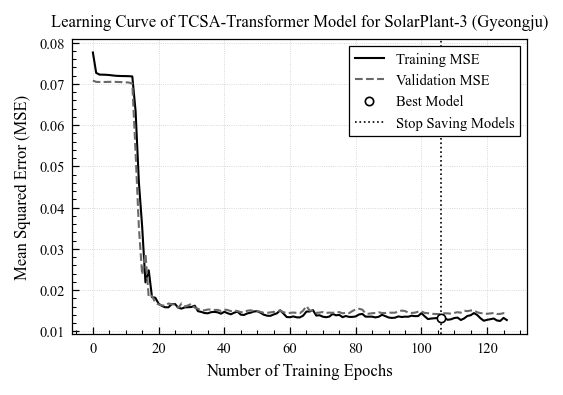

In [ ]:
# Plot the training and validation loss to verify model is well-trained and not overfitted
from Library.modelDevelopment import plot_training_validation_loss
plot_training_validation_loss(history=history, model_Name='TCSA-Transformer Model for SolarPlant-3 (Gyeongju)', patience=20)

In [ ]:
import joblib
model_Scaler = joblib.load(f"{expModelDir}scaler_Site_02.joblib")

from Library.modelDevelopment import evaluate_model
Eval_TCSA_Transformer, Predict_TCSA_Transformer = evaluate_model('TCSA-Transformer', model_TCSA_Transformer, model_Scaler, X_val, y_val)
print(Eval_TCSA_Transformer)

296/296 [==============================] - 1s 3ms/step
              Model       MAE         MSE       RMSE       R2
0  TCSA-Transformer  5.964485  129.255264  11.369049  0.78215
